# Calibrated Markov Model of Antibiotic Resistance
**E. coli / ciprofloxacin, bloodstream infections, South Africa — WHO GLASS data (2018–2023)**

## Setup

In [3]:
import io
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

os.makedirs("figures", exist_ok=True)

## Stage 1 — Data preparation
### Part A: Settings and loading

In [5]:
DATA_FILE    = "data/glass_ecoli_cipro_blood.csv"
COUNTRY      = "South Africa"     # change to "India" for the bonus run
MIN_ISOLATES = 100                # ASSUMPTION: fewer tested samples = unreliable year

def load_glass_timeseries(path):
    # The GLASS file holds two tables; keep only the country-level one
    text = Path(path).read_text(encoding="utf-8")
    country_table = text.split("Data for line plots for individual CTAs")[1].strip()
    return pd.read_csv(io.StringIO(country_table))

raw = load_glass_timeseries(DATA_FILE)
print("Columns:", list(raw.columns))
raw.head()

Columns: ['Iso3', 'CountryTerritoryArea', 'WHORegionName', 'Year', 'Specimen', 'PathogenName', 'AbTargets', 'TotalSpecimenIsolates', 'InterpretableAST', 'Resistant', 'PercentResistant']


,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
0,ARG,Argentina,Region of the Americas,2018,BLOOD,Escherichia coli,Ciprofloxacin,7385,2107,702,33.317513
1,BHR,Bahrain,Eastern Mediterranean Region,2018,BLOOD,Escherichia coli,Ciprofloxacin,633,199,60,30.150754
2,BIH,Bosnia and Herzegovina,European Region,2018,BLOOD,Escherichia coli,Ciprofloxacin,841,243,60,24.691358
3,BRA,Brazil,Region of the Americas,2018,BLOOD,Escherichia coli,Ciprofloxacin,314,100,42,42.000000
4,GEO,Georgia,European Region,2018,BLOOD,Escherichia coli,Ciprofloxacin,216,49,24,48.979592


### Part B: Shares, reliability and the chart

         n     R    NR    p_R   p_NR  margin  low_count
Year                                                   
2018  3628  1032  2596  0.284  0.716   0.015      False
2019  3960  1135  2825  0.287  0.713   0.014      False
2020  4317  1248  3069  0.289  0.711   0.014      False
2021  3940  1122  2818  0.285  0.715   0.014      False
2022  4286  1306  2980  0.305  0.695   0.014      False
2023  4531  1567  2964  0.346  0.654   0.014      False


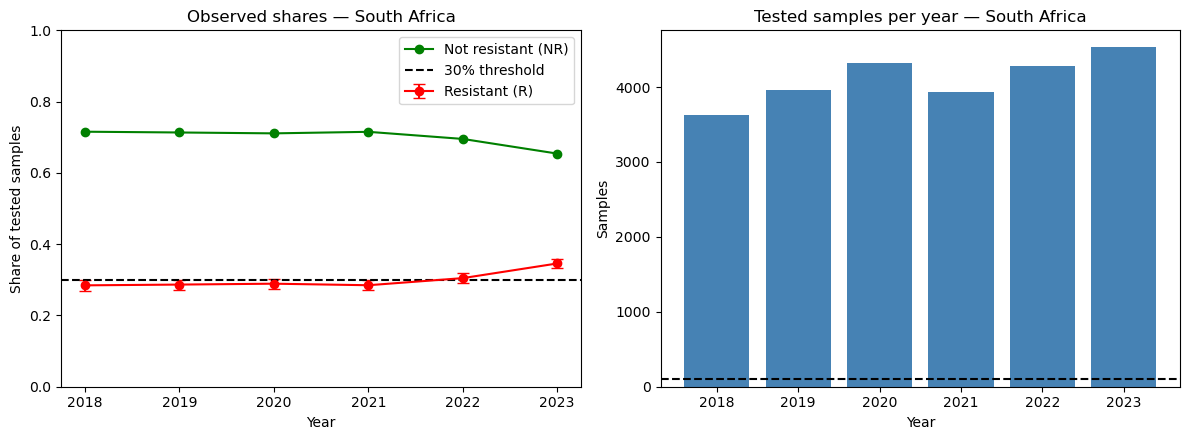

In [7]:
# 1. Keep only our country, and only the columns we need
data = raw[raw["CountryTerritoryArea"] == COUNTRY]
data = data[["Year", "InterpretableAST", "Resistant"]]
data = data.rename(columns={"InterpretableAST": "n", "Resistant": "R"})
data = data.set_index("Year")

# 2. Work out the two states and their shares
data["NR"]   = data["n"] - data["R"]      # not resistant
data["p_R"]  = data["R"]  / data["n"]     # share resistant
data["p_NR"] = data["NR"] / data["n"]     # share not resistant

# 3. How precise is each year? (95% margin of error)
data["margin"] = 1.96 * np.sqrt(data["p_R"] * (1 - data["p_R"]) / data["n"])
data["low_count"] = data["n"] < MIN_ISOLATES

print(data.round(3))

# 4. Two charts side by side
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left chart: both shares over time, with the margin of error for R
left.errorbar(data.index, data["p_R"], yerr=data["margin"],
              fmt="o-", color="red", capsize=4, label="Resistant (R)")
left.plot(data.index, data["p_NR"], "o-", color="green", label="Not resistant (NR)")
left.axhline(0.30, color="black", linestyle="--", label="30% threshold")
left.set_title(f"Observed shares — {COUNTRY}")
left.set_xlabel("Year")
left.set_ylabel("Share of tested samples")
left.set_ylim(0, 1)
left.legend()

# Right chart: how many samples were tested each year
right.bar(data.index, data["n"], color="steelblue")
right.axhline(MIN_ISOLATES, color="black", linestyle="--")
right.set_title(f"Tested samples per year — {COUNTRY}")
right.set_xlabel("Year")
right.set_ylabel("Samples")

plt.tight_layout()
plt.show()

## Stage 2 — Model functions
### Part A: 2-state tables and the n-step function

T1 (drug A)        row sums = [1. 1.]  ->  OK
U (untreated)      row sums = [1. 1.]  ->  OK
T2 (drug B)        row sums = [1. 1.]  ->  OK
TC (combination)   row sums = [1. 1.]  ->  OK

Always drug A (T1), starting from South Africa 2018:
  after  1 years: NR=0.693  R=0.307
  after  2 years: NR=0.671  R=0.329
  after  5 years: NR=0.614  R=0.386
  after 10 years: NR=0.539  R=0.461

Self-check against exact formula: PASSED


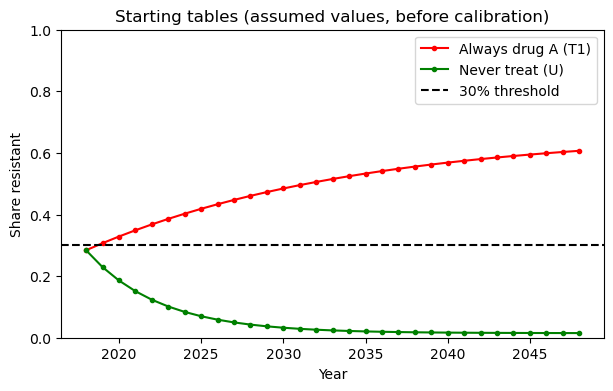

In [9]:
STATES = ["NR", "R"]

# 1. Build a 2x2 table from two numbers
#    a = chance NR -> R in one year
#    b = chance R  -> NR in one year
def make_matrix(a, b):
    return np.array([[1 - a, a],      # from NR
                     [b,     1 - b]]) # from R

# Starting tables — ALL VALUES ARE ASSUMPTIONS (drug A is re-fitted in Stage 3)
T1 = make_matrix(a=0.040, b=0.02)   # drug A
U  = make_matrix(a=0.003, b=0.20)   # untreated
T2 = make_matrix(a=0.030, b=0.03)   # drug B
TC = make_matrix(a=0.015, b=0.05)   # combination product

matrices = {"T1 (drug A)": T1, "U (untreated)": U,
            "T2 (drug B)": T2, "TC (combination)": TC}

# 2. Check: no negative chances, every row adds up to 1
def check_matrix(name, M):
    row_sums = M.sum(axis=1)
    ok = np.allclose(row_sums, 1) and (M >= 0).all()
    print(f"{name:18s} row sums = {row_sums}  ->  {'OK' if ok else 'PROBLEM'}")

for name, M in matrices.items():
    check_matrix(name, M)

# 3. Play the model forward n years with the same table every year
def n_step(start, M, n):
    dist = np.array(start, dtype=float)
    for year in range(n):
        dist = dist @ M          # shares now x chances = shares next year
    return dist

start = [0.716, 0.284]           # South Africa 2018: 71.6% NR, 28.4% R

print("\nAlways drug A (T1), starting from South Africa 2018:")
for n in [1, 2, 5, 10]:
    d = n_step(start, T1, n)
    print(f"  after {n:2d} years: NR={d[0]:.3f}  R={d[1]:.3f}")

# 4. Self-check against the exact 2-state formula
#    R after n years = long_run + (R_start - long_run) * (1 - a - b)^n
def formula_R(R_start, a, b, n):
    long_run = a / (a + b)
    return long_run + (R_start - long_run) * (1 - a - b) ** n

for name, (a, b) in {"T1": (0.040, 0.02), "U": (0.003, 0.20)}.items():
    M = make_matrix(a, b)
    for n in [5, 10]:
        code   = n_step(start, M, n)[1]
        exact  = formula_R(0.284, a, b, n)
        assert abs(code - exact) < 1e-9, f"Self-check FAILED for {name}"
print("\nSelf-check against exact formula: PASSED")

# 5. Picture: resistant share over 30 years, always-treat vs never-treat
years = range(31)
plt.figure(figsize=(7, 4))
plt.plot([2018 + n for n in years], [n_step(start, T1, n)[1] for n in years],
         "o-", ms=3, color="red", label="Always drug A (T1)")
plt.plot([2018 + n for n in years], [n_step(start, U, n)[1] for n in years],
         "o-", ms=3, color="green", label="Never treat (U)")
plt.axhline(0.30, color="black", linestyle="--", label="30% threshold")
plt.title("Starting tables (assumed values, before calibration)")
plt.xlabel("Year")
plt.ylabel("Share resistant")
plt.ylim(0, 1)
plt.legend()
plt.show()

### Part B: Strategies and the long-run answer
*Uses the assumed (uncalibrated) tables — a demonstration of the functions only.*

Check simulate vs n_step: PASSED

Check stationary vs 2,000-year run: PASSED

Long-run resistant share (ASSUMED tables, before calibration):
  U (never treat)      1.5%
  T1 (always drug A)   66.7%
  50/50 mix            16.3%

Resistant share from South Africa 2018 (ASSUMED tables):
  Strategy                   5 yrs  10 yrs
  S1 Always drug A           38.6%   46.1%
  S2 Treat 25%               15.8%   10.7%
  S2 Treat 50%               22.3%   19.3%
  S2 Treat 75%               29.9%   30.8%
  S3 Alternate A / none      24.7%   17.3%
  S4 Rotate A / B            36.8%   42.1%
  S5 Combination             26.9%   25.8%


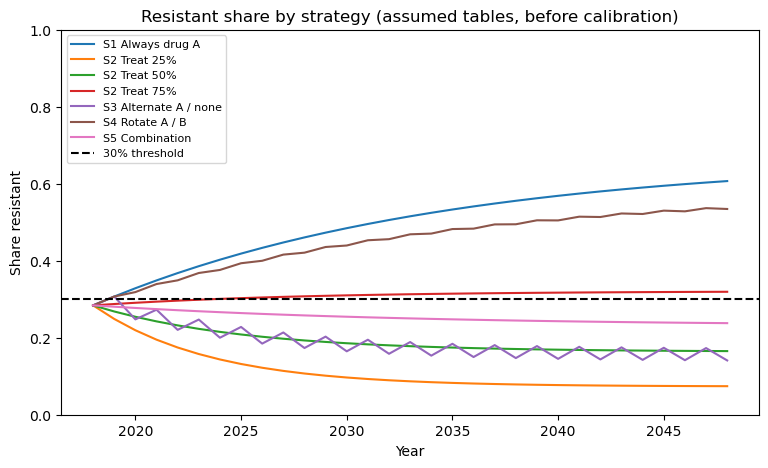

In [11]:
# 1. A strategy = a list of tables that repeats year after year
def mix(p):
    """Treat in a fraction p of cases: blend drug A and untreated."""
    return p * T1 + (1 - p) * U

strategies = {
    "S1 Always drug A":       [T1],
    "S2 Treat 25%":           [mix(0.25)],
    "S2 Treat 50%":           [mix(0.50)],
    "S2 Treat 75%":           [mix(0.75)],
    "S3 Alternate A / none":  [T1, U],
    "S4 Rotate A / B":        [T1, T2],
    "S5 Combination":         [TC],
}

# 2. Simulate any strategy for N years; keep every year's shares
def simulate(start, pattern, n_years):
    dist = np.array(start, dtype=float)
    history = [dist]
    for year in range(n_years):
        M = pattern[year % len(pattern)]   # pick this year's table
        dist = dist @ M
        history.append(dist)
    return np.array(history)               # row = year, columns = NR, R

# Check: a one-table strategy must give the same answer as n_step
assert np.allclose(simulate(start, [T1], 10)[10], n_step(start, T1, 10))
print("Check simulate vs n_step: PASSED\n")

# 3. Long-run (stationary) share: where the model settles if run forever
def stationary(M):
    a, b = M[0, 1], M[1, 0]                # NR->R and R->NR
    pi_R = a / (a + b)
    return np.array([1 - pi_R, pi_R])

# Check: the formula must match running the model for 2,000 years
for M in [T1, U, mix(0.5)]:
    assert np.allclose(stationary(M), n_step(start, M, 2000))
print("Check stationary vs 2,000-year run: PASSED\n")

print("Long-run resistant share (ASSUMED tables, before calibration):")
for name, M in {"U (never treat)": U, "T1 (always drug A)": T1,
                "50/50 mix": mix(0.5)}.items():
    print(f"  {name:20s} {stationary(M)[1]:.1%}")

# 4. Resistant share after 5 and 10 years for every strategy
print("\nResistant share from South Africa 2018 (ASSUMED tables):")
print(f"  {'Strategy':24s} {'5 yrs':>7s} {'10 yrs':>7s}")
for name, pattern in strategies.items():
    h = simulate(start, pattern, 10)
    print(f"  {name:24s} {h[5, 1]:7.1%} {h[10, 1]:7.1%}")

# 5. Picture: resistant share over 30 years for every strategy
plt.figure(figsize=(9, 5))
for name, pattern in strategies.items():
    h = simulate(start, pattern, 30)
    plt.plot(range(2018, 2049), h[:, 1], label=name)
plt.axhline(0.30, color="black", linestyle="--", label="30% threshold")
plt.title("Resistant share by strategy (assumed tables, before calibration)")
plt.xlabel("Year")
plt.ylabel("Share resistant")
plt.ylim(0, 1)
plt.legend(fontsize=8, loc="upper left")
plt.show()

## Stage 3 — Calibration

Best fit: a = 0.0103, b = 0.0000, error = 0.001309
Good fits: 161 pairs
  a from 0.009 to 0.031
  b from 0.000 to 0.050
  long-run resistant share from 38% to 100%

Year  Observed  Fitted  Difference
2018    28.4%    28.4%    +0.0%
2019    28.7%    29.2%    +0.5%
2020    28.9%    29.9%    +1.0%
2021    28.5%    30.6%    +2.2%
2022    30.5%    31.3%    +0.9%
2023    34.6%    32.0%    -2.5%


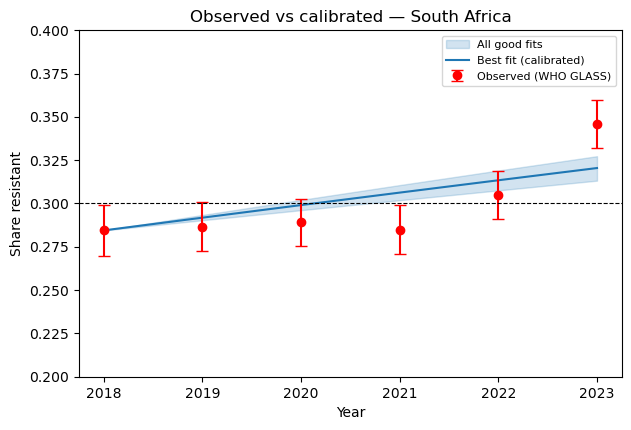

In [13]:
# 1. Observed data from Stage 1
obs   = data
years = obs.index.values
obs_R = obs["p_R"].values

# 2. Model prediction: start at 2018's real value, play forward each year
def predict_R(a, b):
    R = obs_R[0]
    out = [R]
    for _ in range(len(years) - 1):
        R = (1 - R) * a + R * (1 - b)   # inflow from NR + R that stays R
        out.append(R)
    return np.array(out)

# 3. Error: sum of squared differences between model and data
def sse(params):
    a, b = params
    return np.sum((predict_R(a, b) - obs_R) ** 2)

# 4. Search for the best a and b from 20 random starting guesses
rng = np.random.default_rng(0)
best = None
for _ in range(20):
    guess = rng.uniform(0, 0.5, size=2)
    res = minimize(sse, guess, bounds=[(0, 0.5), (0, 0.5)])   # ASSUMPTION: 0 to 0.5
    if best is None or res.fun < best.fun:
        best = res

a_best, b_best = best.x
print(f"Best fit: a = {a_best:.4f}, b = {b_best:.4f}, error = {best.fun:.6f}")

# 5. Range of good fits: try many (a, b) pairs, keep those within 10% of the best
good = []
for a in np.arange(0, 0.101, 0.001):
    for b in np.arange(0, 0.201, 0.001):
        if sse((a, b)) <= 1.10 * best.fun:          # ASSUMPTION: within 10%
            good.append((a, b))
good = np.array(good)

print(f"Good fits: {len(good)} pairs")
print(f"  a from {good[:, 0].min():.3f} to {good[:, 0].max():.3f}")
print(f"  b from {good[:, 1].min():.3f} to {good[:, 1].max():.3f}")
long_run = good[:, 0] / (good[:, 0] + good[:, 1])
print(f"  long-run resistant share from {long_run.min():.0%} to {long_run.max():.0%}")

# 6. Year-by-year comparison
fit_R = predict_R(a_best, b_best)
print("\nYear  Observed  Fitted  Difference")
for y, o, f in zip(years, obs_R, fit_R):
    print(f"{y}   {o:6.1%}   {f:6.1%}   {f - o:+6.1%}")

# 7. Chart: observed vs fitted, with a band covering all good fits
curves = np.array([predict_R(a, b) for a, b in good])
plt.figure(figsize=(7, 4.5))
plt.fill_between(years, curves.min(axis=0), curves.max(axis=0),
                 color="tab:blue", alpha=0.2, label="All good fits")
plt.plot(years, fit_R, color="tab:blue", label="Best fit (calibrated)")
plt.errorbar(years, obs_R, yerr=obs["margin"], fmt="o", color="red",
             capsize=4, label="Observed (WHO GLASS)")
plt.axhline(0.30, color="black", linestyle="--", lw=0.8)
plt.title("Observed vs calibrated — South Africa")
plt.xlabel("Year")
plt.ylabel("Share resistant")
plt.ylim(0.2, 0.4)
plt.legend(fontsize=8)
plt.show()

## Stage 4 — The four analyses (calibrated drug A, starting from 2023)

(a) Resistant share from 2023 (34.6%):
version                 best  high-a end  low-a end
strategy                                           
S1 Always drug A       0.410       0.369      0.403
S2 Treat 25%           0.082       0.099      0.081
S2 Treat 50%           0.149       0.168      0.145
S2 Treat 75%           0.252       0.256      0.246
S3 Alternate A / none  0.137       0.154      0.134
S4 Rotate A / B        0.385       0.338      0.378
S5 Combination         0.278       0.212      0.276

(b) Expected years to resistance under drug A:
  best       97 years
  low-a end  111 years
  high-a end 32 years

(c) Long-run resistant share:
  best       drug A 100.0%   not drug A 0.4%   50/50 mix 5.2%
  low-a end  drug A 100.0%   not drug A 0.3%   50/50 mix 4.6%
  high-a end drug A 38.8%   not drug A 1.1%   50/50 mix 11.8%


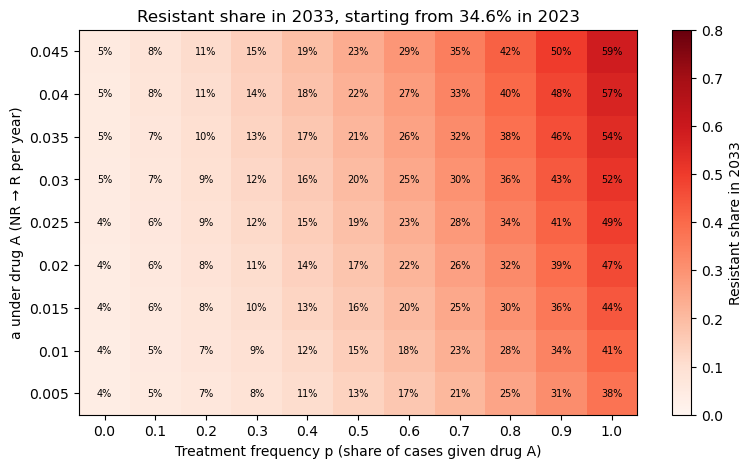

In [15]:
def make_matrix(a, b):
    return np.array([[1 - a, a], [b, 1 - b]])

def simulate(start, pattern, n_years):
    dist = np.array(start, dtype=float)
    history = [dist]
    for year in range(n_years):
        dist = dist @ pattern[year % len(pattern)]
        history.append(dist)
    return np.array(history)

start = [1 - 0.346, 0.346]                      # South Africa 2023

# 1. Three versions of drug A from Stage 3: the best fit and the two ends of the good-fit range
good = pd.DataFrame(good, columns=["a", "b"])
best = pd.Series({"a": a_best, "b": b_best})
versions = {
    "best":    (best.a, best.b),
    "low-a end":  tuple(good.loc[good.a.idxmin()]),   # good fit with the smallest a
    "high-a end": tuple(good.loc[good.a.idxmax()]),   # good fit with the largest a (and largest b)
}

# 2. Strategies for a given drug A (other tables SCALED to drug A — ASSUMPTION)
def get_strategies(a1, b1):
    T1 = make_matrix(a1,         b1)          # drug A (calibrated)
    T2 = make_matrix(0.75 * a1,  b1 + 0.01)   # drug B
    TC = make_matrix(0.375 * a1, b1 + 0.03)   # combination
    U  = make_matrix(0.075 * a1, 0.20)        # not drug A
    return {
        "S1 Always drug A":      [T1],
        "S2 Treat 25%":          [0.25 * T1 + 0.75 * U],
        "S2 Treat 50%":          [0.50 * T1 + 0.50 * U],
        "S2 Treat 75%":          [0.75 * T1 + 0.25 * U],
        "S3 Alternate A / none": [T1, U],
        "S4 Rotate A / B":       [T1, T2],
        "S5 Combination":        [TC],
    }

# (a) Resistant share in 2028 and 2033 for each version of drug A
rows = []
for version, (a1, b1) in versions.items():
    for name, pattern in get_strategies(a1, b1).items():
        h = simulate(start, pattern, 10)
        rows.append([name, version, h[5, 1], h[10, 1]])
table = pd.DataFrame(rows, columns=["strategy", "version", "2028", "2033"])
print("(a) Resistant share from 2023 (34.6%):")
print(table.pivot(index="strategy", columns="version", values="2033").round(3))

# (b) Expected years to resistance = 1 / a
print("\n(b) Expected years to resistance under drug A:")
for version, (a1, b1) in versions.items():
    print(f"  {version:10s} {1 / a1:.0f} years")

# (c) Long-run resistant share = a / (a + b)
print("\n(c) Long-run resistant share:")
for version, (a1, b1) in versions.items():
    aU, bU = 0.075 * a1, 0.20
    a_mix, b_mix = 0.5 * a1 + 0.5 * aU, 0.5 * b1 + 0.5 * bU
    print(f"  {version:10s} drug A {a1/(a1+b1):.1%}   not drug A {aU/(aU+bU):.1%}"
          f"   50/50 mix {a_mix/(a_mix+b_mix):.1%}")

# (d) Heatmap: resistant share in 2033 by treatment frequency p and drug A's a
p_values = np.round(np.arange(0, 1.01, 0.1), 1)
a_values = np.round(np.arange(0.005, 0.0451, 0.005), 3)
heat = np.zeros((len(a_values), len(p_values)))
for i, a1 in enumerate(a_values):
    for j, p in enumerate(p_values):
        M = p * make_matrix(a1, best.b) + (1 - p) * make_matrix(0.075 * a1, 0.20)
        heat[i, j] = simulate(start, [M], 10)[10, 1]

plt.figure(figsize=(9, 5))
plt.imshow(heat, origin="lower", cmap="Reds", aspect="auto", vmin=0, vmax=0.8)
plt.colorbar(label="Resistant share in 2033")
for i in range(len(a_values)):
    for j in range(len(p_values)):
        plt.text(j, i, f"{heat[i, j]:.0%}", ha="center", va="center", fontsize=7)
plt.xticks(range(len(p_values)), p_values)
plt.yticks(range(len(a_values)), a_values)
plt.xlabel("Treatment frequency p (share of cases given drug A)")
plt.ylabel("a under drug A (NR → R per year)")
plt.title("Resistant share in 2033, starting from 34.6% in 2023")
plt.show()
plt.show()

## Stage 5 — Strategy comparison and cost
*All costs are placeholders (assumptions). Threshold changed to 40% because South Africa passed 30% in 2022.*

MAIN RESULT (reversal when not using drug A: b_U = 0.20)
                             reaches 40%  R in 2033  cost (millions)  \
strategy                                                               
S1 Always drug A                    2032      0.410             8.14   
S2 Treat 25%           not within 50 yrs      0.082             4.05   
S2 Treat 50%           not within 50 yrs      0.149             5.04   
S2 Treat 75%           not within 50 yrs      0.252             6.37   
S3 Alternate A / none  not within 50 yrs      0.137             5.17   
S4 Rotate A / B                     2038      0.385             7.88   
S5 Combination         not within 50 yrs      0.278             7.64   

                       cost rank  
strategy                          
S1 Always drug A               7  
S2 Treat 25%                   1  
S2 Treat 50%                   2  
S2 Treat 75%                   4  
S3 Alternate A / none          3  
S4 Rotate A / B                6  
S5 Combination

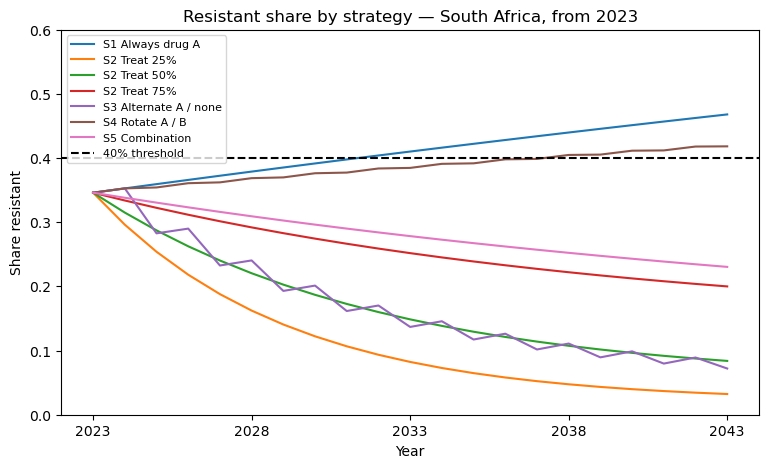

In [17]:
def make_matrix(a, b):
    return np.array([[1 - a, a], [b, 1 - b]])

START = 0.346          # South Africa 2023 resistant share
THRESHOLD = 0.40       # ASSUMPTION: SA already passed 30%, so we use 40%

# 1. Placeholder costs — ALL ASSUMPTIONS, replace with real values
COST = {
    "drug_A":      50,     # per patient per year treated with drug A
    "drug_B":      50,     # per patient per year treated with drug B
    "combination": 150,    # drug A cost + 100 extra for the combination
    "alternative": 80,     # patients NOT given drug A get another antibiotic
    "resistant":   2000,   # extra cost of each resistant infection
}

# 2. Strategies: each year = (table, drug cost per patient)
def get_strategies(b_U, cost):
    a1, b1 = best.a, best.b
    T1 = make_matrix(a1, b1)
    T2 = make_matrix(0.75 * a1, b1 + 0.01)
    TC = make_matrix(0.375 * a1, b1 + 0.03)
    U  = make_matrix(0.075 * a1, b_U)
    def mix(p):
        return (p * T1 + (1 - p) * U, p * cost["drug_A"] + (1 - p) * cost["alternative"])
    return {
        "S1 Always drug A":      [(T1, cost["drug_A"])],
        "S2 Treat 25%":          [mix(0.25)],
        "S2 Treat 50%":          [mix(0.50)],
        "S2 Treat 75%":          [mix(0.75)],
        "S3 Alternate A / none": [(T1, cost["drug_A"]), (U, cost["alternative"])],
        "S4 Rotate A / B":       [(T1, cost["drug_A"]), (T2, cost["drug_B"])],
        "S5 Combination":        [(TC, cost["combination"])],
    }

# 3. Run one strategy: years to threshold, resistance in 2033, cost per 1,000 patients
def run(pattern, cost, years=50):
    dist = np.array([1 - START, START])
    first_year, total_cost, R_2033 = None, 0, None
    for year in range(years):
        M, drug_cost = pattern[year % len(pattern)]
        dist = dist @ M
        if year < 10:                                   # cost over 10 years
            total_cost += 1000 * (drug_cost + dist[1] * cost["resistant"])
        if year == 9:
            R_2033 = dist[1]
        if first_year is None and dist[1] >= THRESHOLD:
            first_year = 2023 + year + 1
    return first_year or "not within 50 yrs", R_2033, total_cost

def compare(b_U=0.20, cost=COST):
    rows = []
    for name, pattern in get_strategies(b_U, cost).items():
        year, R, c = run(pattern, cost)
        rows.append([name, year, round(R, 3), round(c / 1e6, 2)])
    df = pd.DataFrame(rows, columns=["strategy", "reaches 40%", "R in 2033", "cost (millions)"])
    df["cost rank"] = df["cost (millions)"].rank().astype(int)
    return df.set_index("strategy")

# 4. Main result
print("MAIN RESULT (reversal when not using drug A: b_U = 0.20)")
print(compare(), "\n")

# 5. Sensitivity 1: resistance hardly reverses (b_U = 0.02)
print("SENSITIVITY 1: b_U = 0.02 (resistance fades slowly)")
print(compare(b_U=0.02), "\n")

# 6. Sensitivity 2: resistant infections cost half as much (1,000)
print("SENSITIVITY 2: cost per resistant infection = 1,000")
print(compare(cost={**COST, "resistant": 1000}))

# 7. Chart: resistant share by strategy, 2023-2043 (main result)
plt.figure(figsize=(9, 5))
for name, pattern in get_strategies(0.20, COST).items():
    dist, path = np.array([1 - START, START]), [START]
    for year in range(20):
        dist = dist @ pattern[year % len(pattern)][0]
        path.append(dist[1])
    plt.plot(range(2023, 2044), path, label=name)
plt.axhline(THRESHOLD, color="black", linestyle="--", label="40% threshold")
plt.title("Resistant share by strategy — South Africa, from 2023")
plt.xticks(range(2023, 2044, 5))
plt.xlabel("Year")
plt.ylabel("Share resistant")
plt.ylim(0, 0.6)
plt.legend(fontsize=8)
plt.show()